In [1]:
from __future__ import annotations

import logging
from pathlib import Path
from tqdm import tqdm

import pandas as pd
import matplotlib.pyplot as plt
import importlib
import src.ddm.ddm

importlib.reload(src.ddm.ddm)

import numpy as np

from config import dir_config, main_config

from src.ddm.utils import build_stimulus, prepare_data, load_model

logging.basicConfig(level=logging.INFO)
logger = logging.getLogger(__name__)

In [2]:
# change directory to project root
import os

cwd = Path.cwd()
if cwd.name == "notebooks":
    os.chdir(cwd.parent)

In [ ]:
processed_dir = Path(dir_config.data.processed)
ddm_dir = processed_dir / "ddm"

behavior_df = pd.read_csv(ddm_dir / "behavior_data.csv")

best_model = main_config.DDM_MODELING.final_model

In [ ]:
model_dir = ddm_dir / best_model

In [13]:
def plot_ddm_fit(data, sim, title="DDM Fit"):
    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 4))

    cohs_sorted = sorted(data["signed_coherence"].unique())

    def summarize(df):
        p_upper = []
        mean_rt_upper, sem_rt_upper = [], []
        mean_rt_lower, sem_rt_lower = [], []
        for c in cohs_sorted:
            subset = df[df["signed_coherence"] == c].dropna(subset=["rt", "choice"])
            p_upper.append((subset["choice"] == 1).mean() if len(subset) > 0 else np.nan)
            upper = subset[subset["choice"] == 1]["rt"]
            lower = subset[subset["choice"] == 0]["rt"]
            mean_rt_upper.append(upper.mean() if len(upper) > 0 else np.nan)
            sem_rt_upper.append(upper.sem() if len(upper) > 0 else np.nan)
            mean_rt_lower.append(lower.mean() if len(lower) > 0 else np.nan)
            sem_rt_lower.append(lower.sem() if len(lower) > 0 else np.nan)
        return np.array(p_upper), np.array(mean_rt_upper), np.array(sem_rt_upper), np.array(mean_rt_lower), np.array(sem_rt_lower)

    def get_subset(df, outcome):
        if outcome == "correct":
            return df[((df["choice"] == 1) & (df["signed_coherence"] > 0)) | ((df["choice"] == 0) & (df["signed_coherence"] < 0)) | (df["signed_coherence"] == 0)]
        elif outcome == "incorrect":
            return df[((df["choice"] == 0) & (df["signed_coherence"] > 0)) | ((df["choice"] == 1) & (df["signed_coherence"] < 0)) | (df["signed_coherence"] == 0)]
        else:
            raise ValueError("Outcome must be 'correct' or 'incorrect'")

    def summarize2(df, outcome):
        df = get_subset(df, outcome)
        mean_rt, sem_rt = [], []
        for c in cohs_sorted:
            subset = df[df["signed_coherence"] == c].dropna(subset=["rt", "choice"])
            mean_rt.append(subset["rt"].mean() if len(subset) > 0 else np.nan)
            sem_rt.append(subset["rt"].sem() if len(subset) > 0 else np.nan)
        return np.array(mean_rt), np.array(sem_rt)

    def plot_chromo_sem(x, y, yerr, color, label, ax):
        ax.plot(x, y, "o-", color=color, label=label)
        ax.fill_between(x, y - yerr, y + yerr, color=color, alpha=0.2)

    d_p_upper, d_mean_rt_upper, d_sem_rt_upper, d_mean_rt_lower, d_sem_rt_lower = summarize(data)
    s_p_upper, s_mean_rt_upper, s_sem_rt_upper, s_mean_rt_lower, s_sem_rt_lower = summarize(sim)

    # Psychometric function
    ax1.plot(cohs_sorted, d_p_upper, "o-", color="steelblue", label="Data")
    ax1.plot(cohs_sorted, s_p_upper, "-", color="tomato", label="Model")
    ax1.axhline(0.5, color="gray", linestyle="--", linewidth=0.8)
    ax1.axvline(0.0, color="gray", linestyle="--", linewidth=0.8)
    ax1.set(xlabel="Coherence", ylabel="P(upper boundary)", title="Psychometric Function", ylim=(0, 1))

    d_mean_rt_correct, d_sem_rt_correct = summarize2(data, "correct")
    d_mean_rt_incorrect, d_sem_rt_incorrect = summarize2(data, "incorrect")
    s_mean_rt_correct, s_sem_rt_correct = summarize2(sim, "correct")
    s_mean_rt_incorrect, s_sem_rt_incorrect = summarize2(sim, "incorrect")

    plot_chromo_sem(cohs_sorted, d_mean_rt_correct, d_sem_rt_correct, color="steelblue", label="Data", ax=ax2)
    plot_chromo_sem(cohs_sorted, s_mean_rt_correct, s_sem_rt_correct, color="tomato", label="Model", ax=ax2)
    plot_chromo_sem(cohs_sorted, d_mean_rt_incorrect, d_sem_rt_incorrect, color="steelblue", label="Data", ax=ax3)
    plot_chromo_sem(cohs_sorted, s_mean_rt_incorrect, s_sem_rt_incorrect, color="tomato", label="Model", ax=ax3)

    ax2.set(xlabel="Coherence", ylabel="Mean RT (s)", title="Chronometric - Correct Trials")
    ax3.set(xlabel="Coherence", ylabel="Mean RT (s)", title="Chronometric - Incorrect Trials")

    y_min = min(ax2.get_ylim()[0], ax3.get_ylim()[0])
    y_max = max(ax2.get_ylim()[1], ax3.get_ylim()[1])
    ax2.set_ylim(y_min, y_max)
    ax3.set_ylim(y_min, y_max)

    ax3.legend(bbox_to_anchor=(1.05, 1), loc="upper left")

    for ax in [ax1, ax2, ax3]:
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

    plt.suptitle(title)
    plt.tight_layout()
    return fig

In [14]:
def get_simulated_data(model_struct, behavior_df):
    session_data = prepare_data(
        behavior_df,
        session_id=model_struct["job"]["session_id"],
        color=int(model_struct["job"]["color"]),
    )
    stimulus = build_stimulus(session_data)
    sim_data = model_struct["model"].simulate(stimulus=stimulus, params=model_struct["results"]["parameters"], n_reps=1)
    return session_data, pd.DataFrame(sim_data)

In [ ]:
import seaborn as sns
from scipy.stats import ttest_rel
from matplotlib.patches import Patch


def load_model_data(model_dir, behavior_df, plot_individual_fits=False):
    fitted_params, d_data, s_data = [], [], []

    for model_path in tqdm(sorted(model_dir.rglob("*.pkl")), desc=f"Loading {model_dir.name}", unit="file"):
        try:
            model_struct = load_model(model_path)
            session_id = model_struct["job"]["session_id"]
            color = model_struct["job"]["color"]
            fitted_params.append({"session_id": session_id, "prior_block": color, **model_struct["results"]["parameters"]})
        except Exception as e:
            print(f"Error loading {model_path}: {e}")
            continue

        d_session, s_session = get_simulated_data(model_struct, behavior_df)
        d_session["session_id"] = s_session["session_id"] = session_id
        d_session["color"] = s_session["color"] = color
        d_data.append(d_session)
        s_data.append(s_session)

        if plot_individual_fits:
            plot_ddm_fit(d_session, s_session, title=f"DDM Fit: {session_id} | prior_block={color}")
            plt.show()

    return (pd.DataFrame(fitted_params), pd.concat(d_data, ignore_index=True), pd.concat(s_data, ignore_index=True))


def plot_param_comparison(fitted_params, model_name=""):

    eq_color, uq_color = "gray", "black"

    ignore_cols = ["session_id", "prior_block", "dt", "variance"]

    equal_block = fitted_params.groupby("session_id").apply(lambda df: df[df["prior_block"] == 0].iloc[0] if len(df) == 2 else None).dropna().reset_index(drop=True)
    unequal_block = fitted_params.groupby("session_id").apply(lambda df: df[df["prior_block"] == 1].iloc[0] if len(df) == 2 else None).dropna().reset_index(drop=True)

    param_cols = [c for c in fitted_params.columns if c not in ignore_cols]
    fig, axs = plt.subplots(1, len(param_cols), figsize=(5 * len(param_cols), 5))
    if len(param_cols) == 1:
        axs = [axs]

    for ax_idx, col in enumerate(param_cols):
        t_stat, t_p_value = ttest_rel(equal_block[col], unequal_block[col])
        means = [equal_block[col].mean(), unequal_block[col].mean()]
        sems = [equal_block[col].sem(), unequal_block[col].sem()]

        sns.barplot(x=["Equal Block", "Unequal Block"], y=means, yerr=sems, palette=[eq_color, uq_color], ax=axs[ax_idx])
        p_str = f"{t_p_value:.3f}" if not np.isnan(t_p_value) else "n/a"
        axs[ax_idx].set_ylabel(col)
        axs[ax_idx].set_title(f"{col}\np = {p_str}", fontsize=12)
        axs[ax_idx].spines["top"].set_visible(False)
        axs[ax_idx].spines["right"].set_visible(False)

    handles = [Patch(color=eq_color, label="Equal Block"), Patch(color=uq_color, label="Unequal Block")]
    axs[-1].legend(handles=handles, loc="upper left", bbox_to_anchor=(1.02, 1), borderaxespad=0, frameon=False)

    if model_name:
        plt.suptitle(model_name)
    plt.tight_layout()
    return fig


def plot_session_fits(session_id, d_data, s_data):
    """Psychometric + chronometric for both prior blocks of a single session."""
    fig, axs = plt.subplots(2, 3, figsize=(18, 8))

    for row, color in enumerate([0, 1]):
        block_label = "Equal Block" if color == 0 else "Unequal Block"
        d = d_data[(d_data["session_id"] == session_id) & (d_data["color"] == color)]
        s = s_data[(s_data["session_id"] == session_id) & (s_data["color"] == color)]

        if d.empty:
            for ax in axs[row]:
                ax.set_visible(False)
            continue

        cohs = sorted(d["signed_coherence"].unique())

        def p_upper(df):
            return [(df[df["signed_coherence"] == c]["choice"] == 1).mean() if len(df[df["signed_coherence"] == c]) > 0 else np.nan for c in cohs]

        def chrono(df, correct=True):
            rts, sems = [], []
            for c in cohs:
                sub = df[df["signed_coherence"] == c].dropna(subset=["rt", "choice"])
                if correct:
                    sub = sub[((sub["choice"] == 1) & (sub["signed_coherence"] > 0)) | ((sub["choice"] == 0) & (sub["signed_coherence"] < 0)) | (sub["signed_coherence"] == 0)]
                else:
                    sub = sub[((sub["choice"] == 0) & (sub["signed_coherence"] > 0)) | ((sub["choice"] == 1) & (sub["signed_coherence"] < 0)) | (sub["signed_coherence"] == 0)]
                rts.append(sub["rt"].mean() if len(sub) > 0 else np.nan)
                sems.append(sub["rt"].sem() if len(sub) > 0 else np.nan)
            return np.array(rts), np.array(sems)

        ax1, ax2, ax3 = axs[row]

        ax1.plot(cohs, p_upper(d), "o-", color="steelblue", label="Data")
        ax1.plot(cohs, p_upper(s), "-", color="tomato", label="Model")
        ax1.axhline(0.5, color="gray", linestyle="--", linewidth=0.8)
        ax1.axvline(0.0, color="gray", linestyle="--", linewidth=0.8)
        ax1.set(xlabel="Coherence", ylabel="P(upper boundary)", title=f"{block_label} — Psychometric", ylim=(0, 1))

        for ax, correct in [(ax2, True), (ax3, False)]:
            d_rt, d_sem = chrono(d, correct)
            s_rt, s_sem = chrono(s, correct)
            ax.plot(cohs, d_rt, "o-", color="steelblue", label="Data")
            ax.fill_between(cohs, d_rt - d_sem, d_rt + d_sem, color="steelblue", alpha=0.2)
            ax.plot(cohs, s_rt, "o-", color="tomato", label="Model")
            ax.fill_between(cohs, s_rt - s_sem, s_rt + s_sem, color="tomato", alpha=0.2)
            ax.set(xlabel="Coherence", ylabel="Mean RT (s)", title=f"{block_label} — Chronometric ({'Correct' if correct else 'Incorrect'})")

        ax3.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
        for ax in [ax1, ax2, ax3]:
            ax.spines["top"].set_visible(False)
            ax.spines["right"].set_visible(False)

    plt.suptitle(f"Session: {session_id}", fontsize=14)
    plt.tight_layout()
    return fig

## All sessions combined

Loading leak-1_tc-1:   0%|          | 0/200 [00:00<?, ?file/s]

Loading leak-1_tc-1: 100%|██████████| 200/200 [01:40<00:00,  1.99file/s]


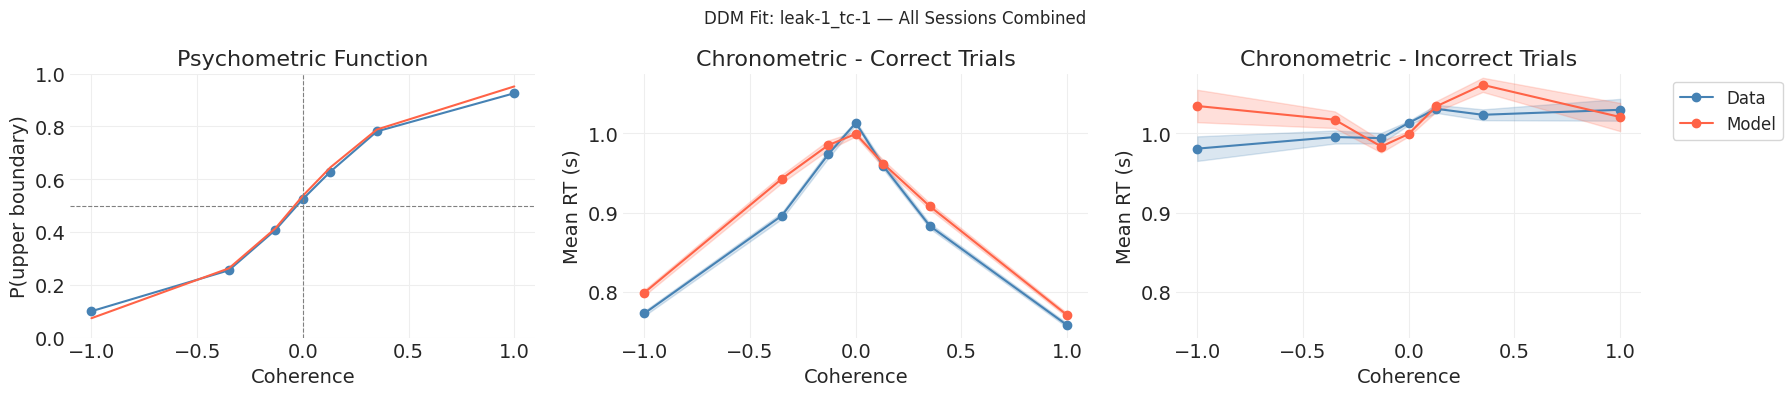

In [17]:
fitted_params, d_data, s_data = load_model_data(model_dir, behavior_df)

fit_fig_all = plot_ddm_fit(data=d_data, sim=s_data, title=f"DDM Fit: {best_model} — All Sessions Combined")

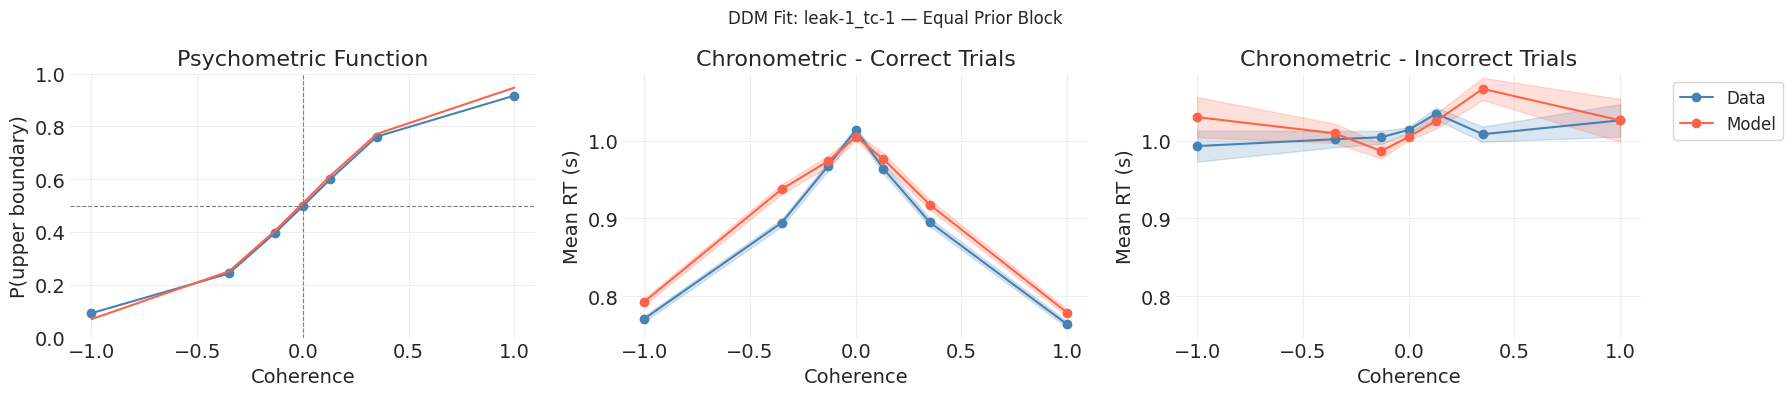

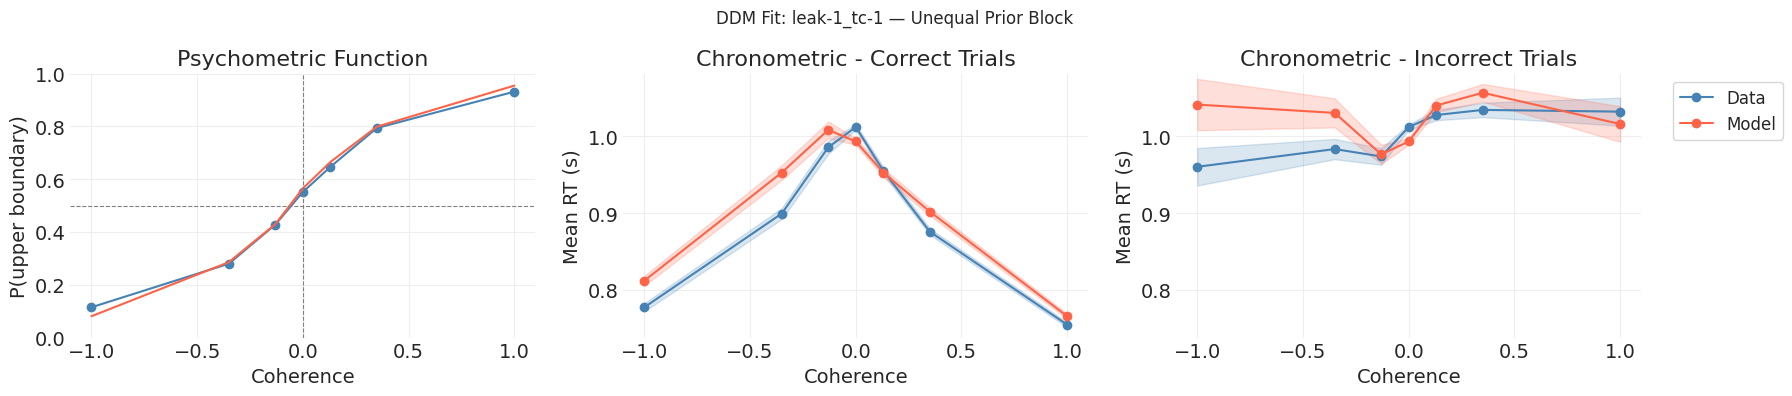

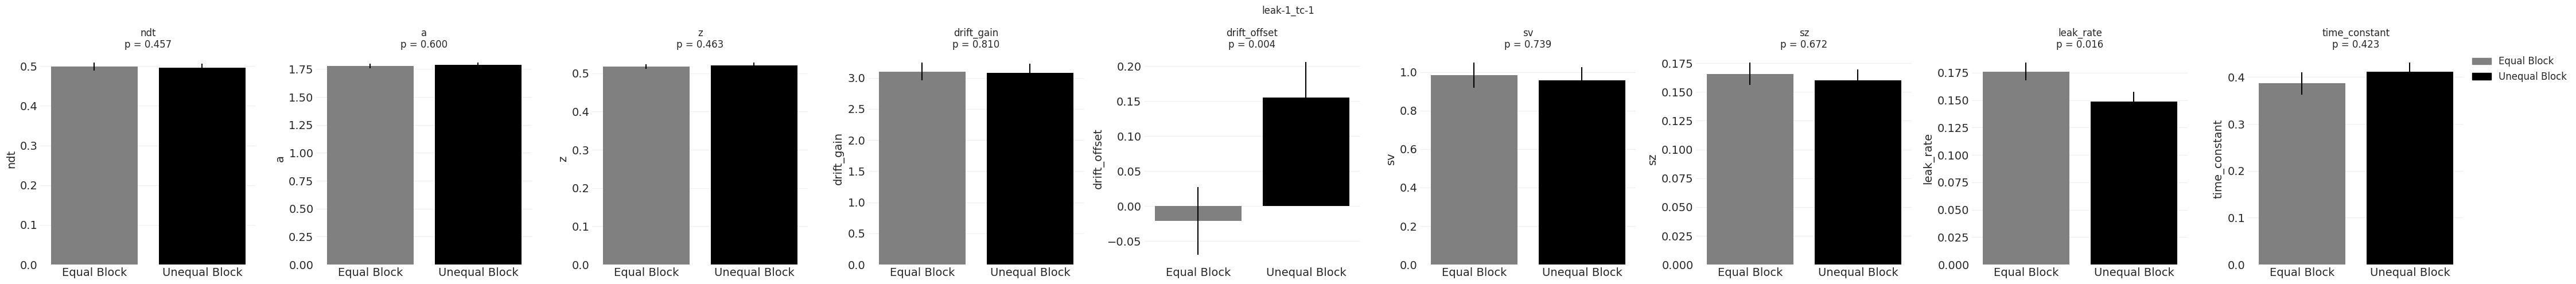

In [18]:
fit_fig_equal = plot_ddm_fit(
    data=d_data[d_data["color"] == 0],
    sim=s_data[s_data["color"] == 0],
    title=f"DDM Fit: {best_model} — Equal Prior Block",
)

fit_fig_unequal = plot_ddm_fit(
    data=d_data[d_data["color"] == 1],
    sim=s_data[s_data["color"] == 1],
    title=f"DDM Fit: {best_model} — Unequal Prior Block",
)
param_fig = plot_param_comparison(fitted_params, model_name=best_model)

## Session-wise comparison

Plotting sessions:   0%|          | 0/100 [00:00<?, ?it/s]

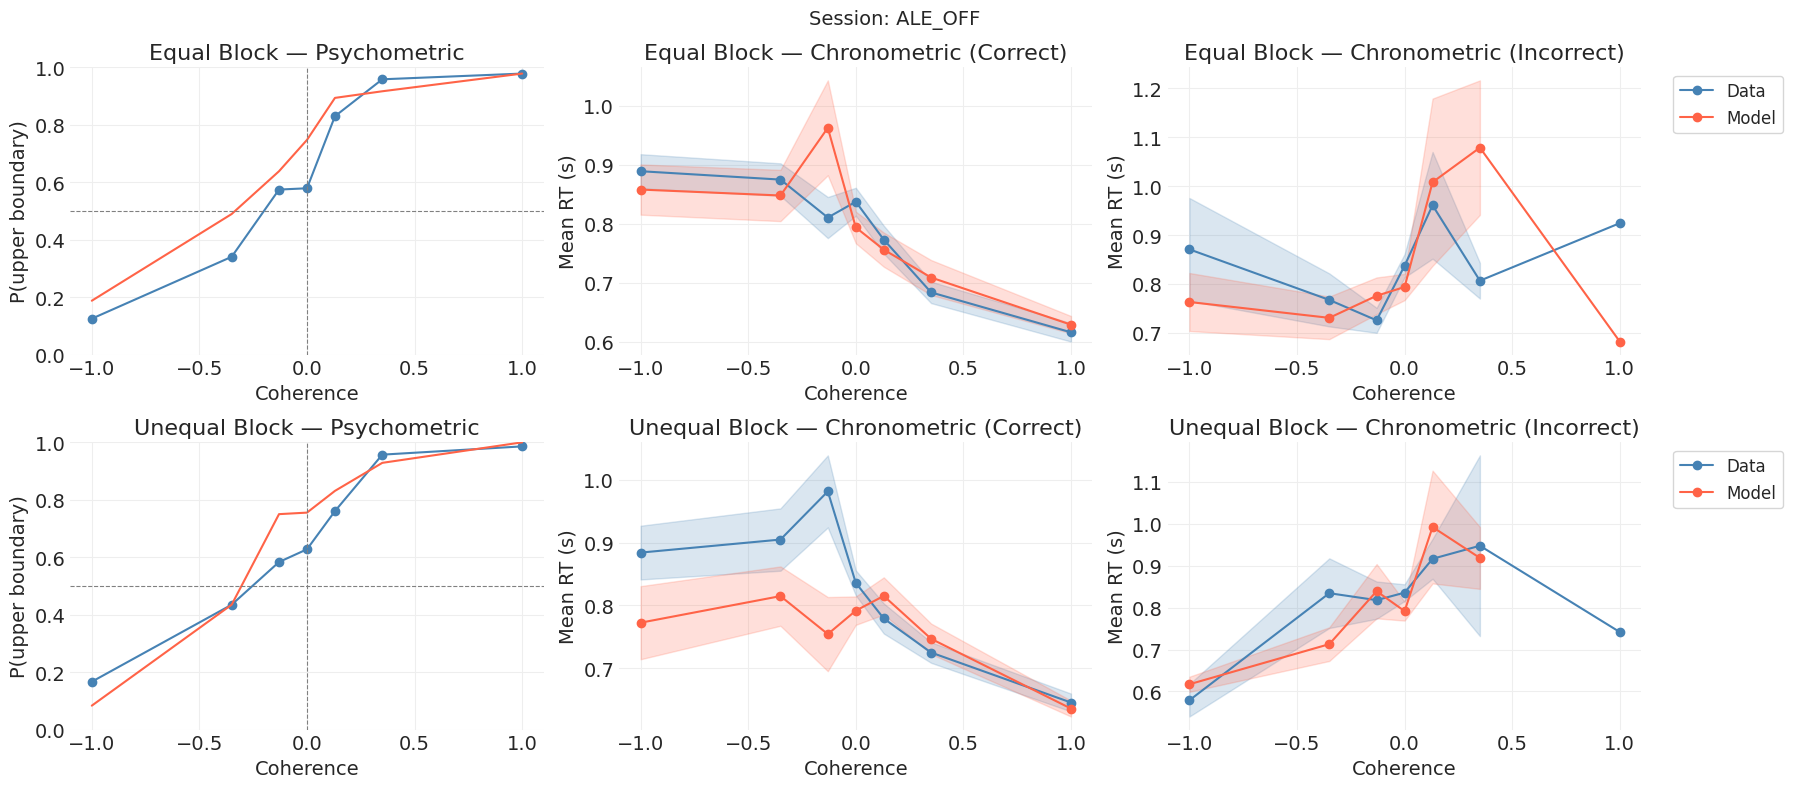

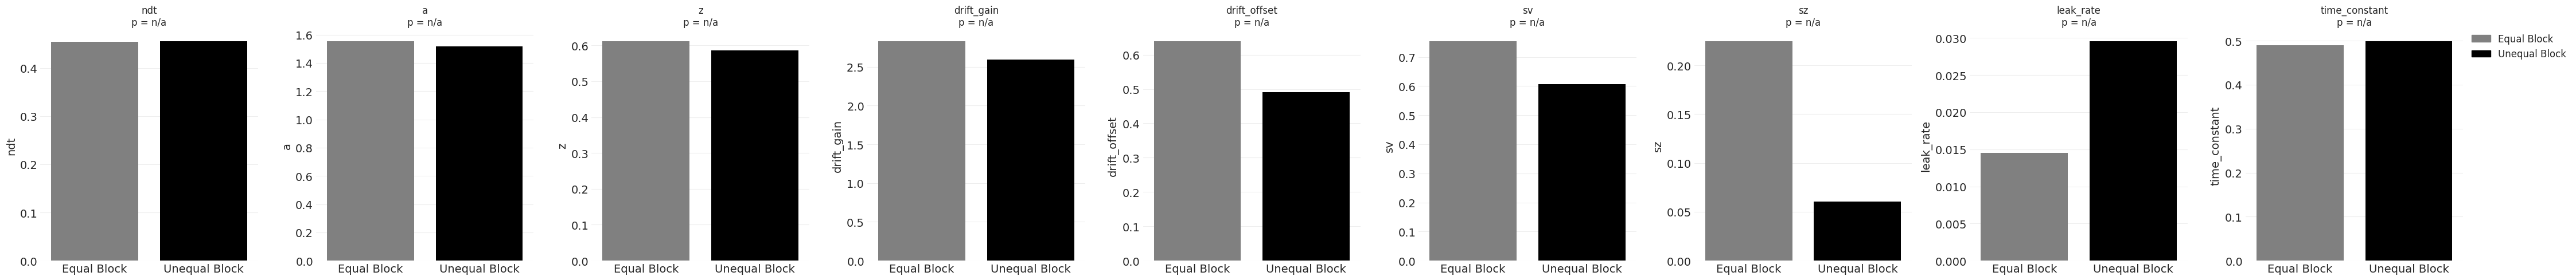

Plotting sessions:   0%|          | 0/100 [00:01<?, ?it/s]


In [ ]:
session_figures = {}
param_figures = {}

for session_id in tqdm(sorted(fitted_params["session_id"].unique()), desc="Plotting sessions"):
    fig = plot_session_fits(session_id, d_data, s_data)
    session_figures[session_id] = fig

    param_figures[session_id] = plot_param_comparison(fitted_params[fitted_params["session_id"] == session_id])
    plt.show()

### Export to ppt

In [ ]:
# from pptx import Presentation
# from pptx.util import Inches, Pt
# from pptx.enum.text import PP_ALIGN
# import io


# def save_to_pptx(fit_fig_all, fit_fig_equal, fit_fig_unequal, param_fig, session_figures, param_figures, output_path="ddm_session_fits.pptx"):
#     prs = Presentation()
#     prs.slide_width = Inches(13.33)
#     prs.slide_height = Inches(7.5)
#     blank = prs.slide_layouts[6]

#     def _buf(fig):
#         buf = io.BytesIO()
#         fig.savefig(buf, format="png", dpi=150, bbox_inches="tight")
#         buf.seek(0)
#         return buf

#     def _title(slide, text):
#         txBox = slide.shapes.add_textbox(Inches(0.3), Inches(0.05), Inches(12.7), Inches(0.4))
#         tf = txBox.text_frame
#         tf.text = text
#         tf.paragraphs[0].alignment = PP_ALIGN.CENTER
#         tf.paragraphs[0].runs[0].font.size = Pt(18)
#         tf.paragraphs[0].runs[0].font.bold = True

#     def add_slide(fig, title_text):
#         slide = prs.slides.add_slide(blank)
#         _title(slide, title_text)
#         slide.shapes.add_picture(_buf(fig), Inches(0.3), Inches(0.55), width=Inches(12.7))

#     def add_summary_slide(fit_fig, param_fig, title_text):
#         slide = prs.slides.add_slide(blank)
#         _title(slide, title_text)
#         for fig, top in [(fit_fig, Inches(0.55)), (param_fig, Inches(4.0))]:
#             slide.shapes.add_picture(_buf(fig), Inches(0.3), top, width=Inches(12.7))

#     def add_session_slide(fit_fig, param_fig, title_text):
#         """Session slide: fit plots pinned to top half, params pinned to bottom — explicit heights prevent overlap."""
#         slide = prs.slides.add_slide(blank)
#         _title(slide, title_text)
#         slide.shapes.add_picture(_buf(fit_fig), Inches(0.3), Inches(0.55), width=Inches(12.7), height=Inches(3.7))
#         slide.shapes.add_picture(_buf(param_fig), Inches(0.3), Inches(4.4), width=Inches(12.7), height=Inches(2.9))

#     # Summary slides
#     add_slide(fit_fig_all, f"{best_model} — All Sessions Combined")
#     add_summary_slide(fit_fig_equal, param_fig, f"{best_model} — Equal Block + Parameters")
#     add_summary_slide(fit_fig_unequal, param_fig, f"{best_model} — Unequal Block + Parameters")

#     # Per-session slides
#     for session_id, fit_fig in session_figures.items():
#         p_fig = param_figures.get(session_id)
#         if p_fig is not None:
#             add_session_slide(fit_fig, p_fig, f"Session: {session_id}")
#         else:
#             add_slide(fit_fig, f"Session: {session_id}")

#     Path(output_path).parent.mkdir(parents=True, exist_ok=True)
#     prs.save(output_path)
#     print(f"Saved {len(prs.slides)} slides → {output_path}")


# output_path = "../dissemination/ddm/ddm_session_fits.pptx"
# save_to_pptx(fit_fig_all, fit_fig_equal, fit_fig_unequal, param_fig, session_figures, param_figures, output_path=output_path)
